# This jupyter notebook serves as an example of a FIR analysis workflow

The data can be found under in folder.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import firAnalysisModule as modFIR
import numpy as np
import matplotlib.pyplot as plt

In [3]:
xrdFileGOS  = ROOT/"in"/"xrdGD2O2S.csv" #the data needs to be in excel or csv format
filenameGOS = ROOT/"in"/"TempEmMap-GOS-upconversion_EX980nm.txt"

## XRD diagram

In [4]:
xrdDataGOS = modFIR.readXrdFile(xrdFileGOS)
xrdDataGOS

,angle,intensity
0,4.00,383.333333
1,4.02,393.333333
2,4.04,353.333333
3,4.06,388.333333
4,4.08,373.333333
...,...,...
4296,89.92,211.666667
4297,89.94,228.333333
4298,89.96,201.666667
4299,89.98,195.000000


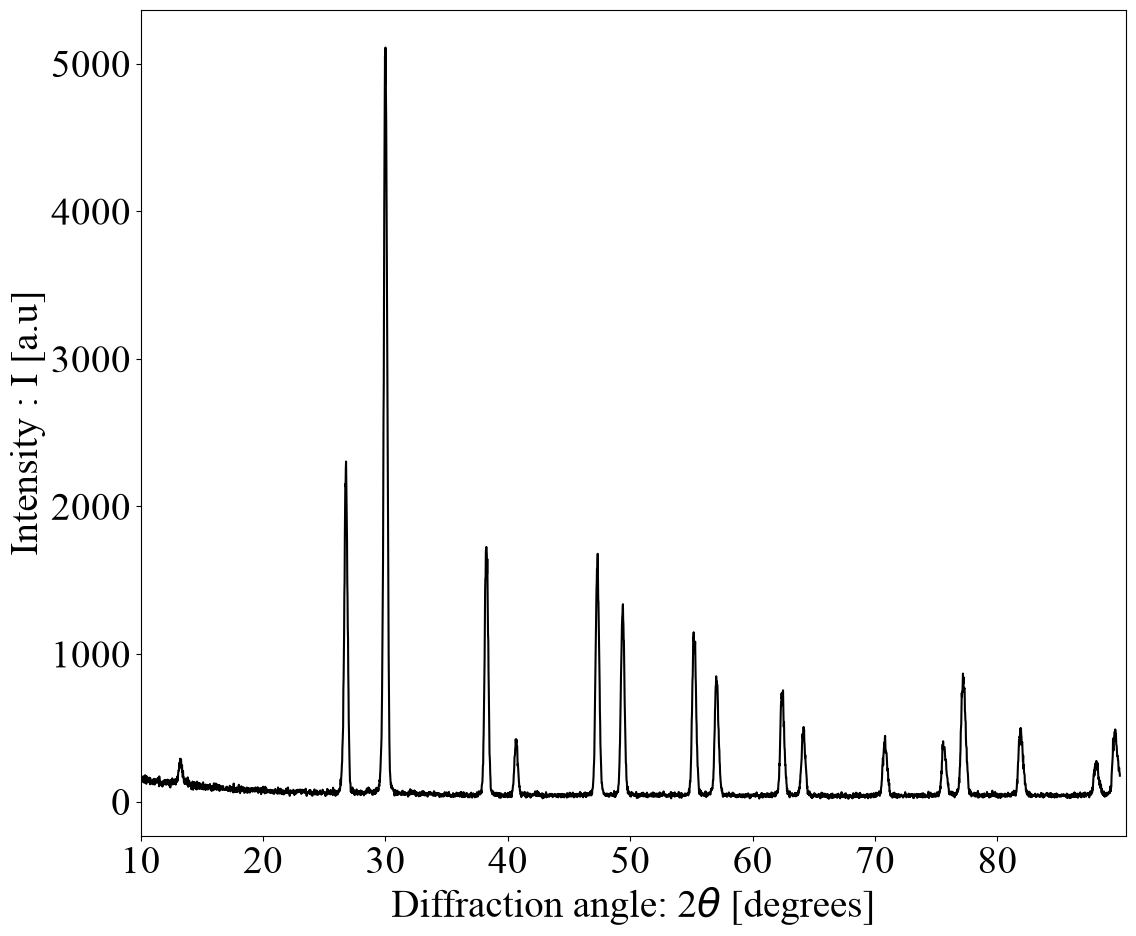

In [5]:
modFIR.plotXRD(xrdDataGOS)
# modFIR.plotXRD(xrdDataGOS, saveFigure=True, saveName="out/xrdImage.pdf") #ensure the out folder exists if you want to save to out

## FIR analysis

In [6]:
gosArr, gosTemp = modFIR.readEmissionTextFile(filenameGOS)

print(gosTemp)

2
num of wavelengths :  501  number of temperatures available :  32
[-175. -150. -125. -100.  -75.  -50.  -25.    0.   25.   50.   75.  100.
  125.  150.  175.  200.  225.  250.  275.  300.  325.  350.  375.  400.
  425.  450.  475.  500.  525.  550.  575.  600.]


In [7]:
# ! pip install --upgrade nbformat

In [8]:
modFIR.graphCountsVsWavelength(gosArr, gosTemp, usePlotly=True, saveGraph=False)

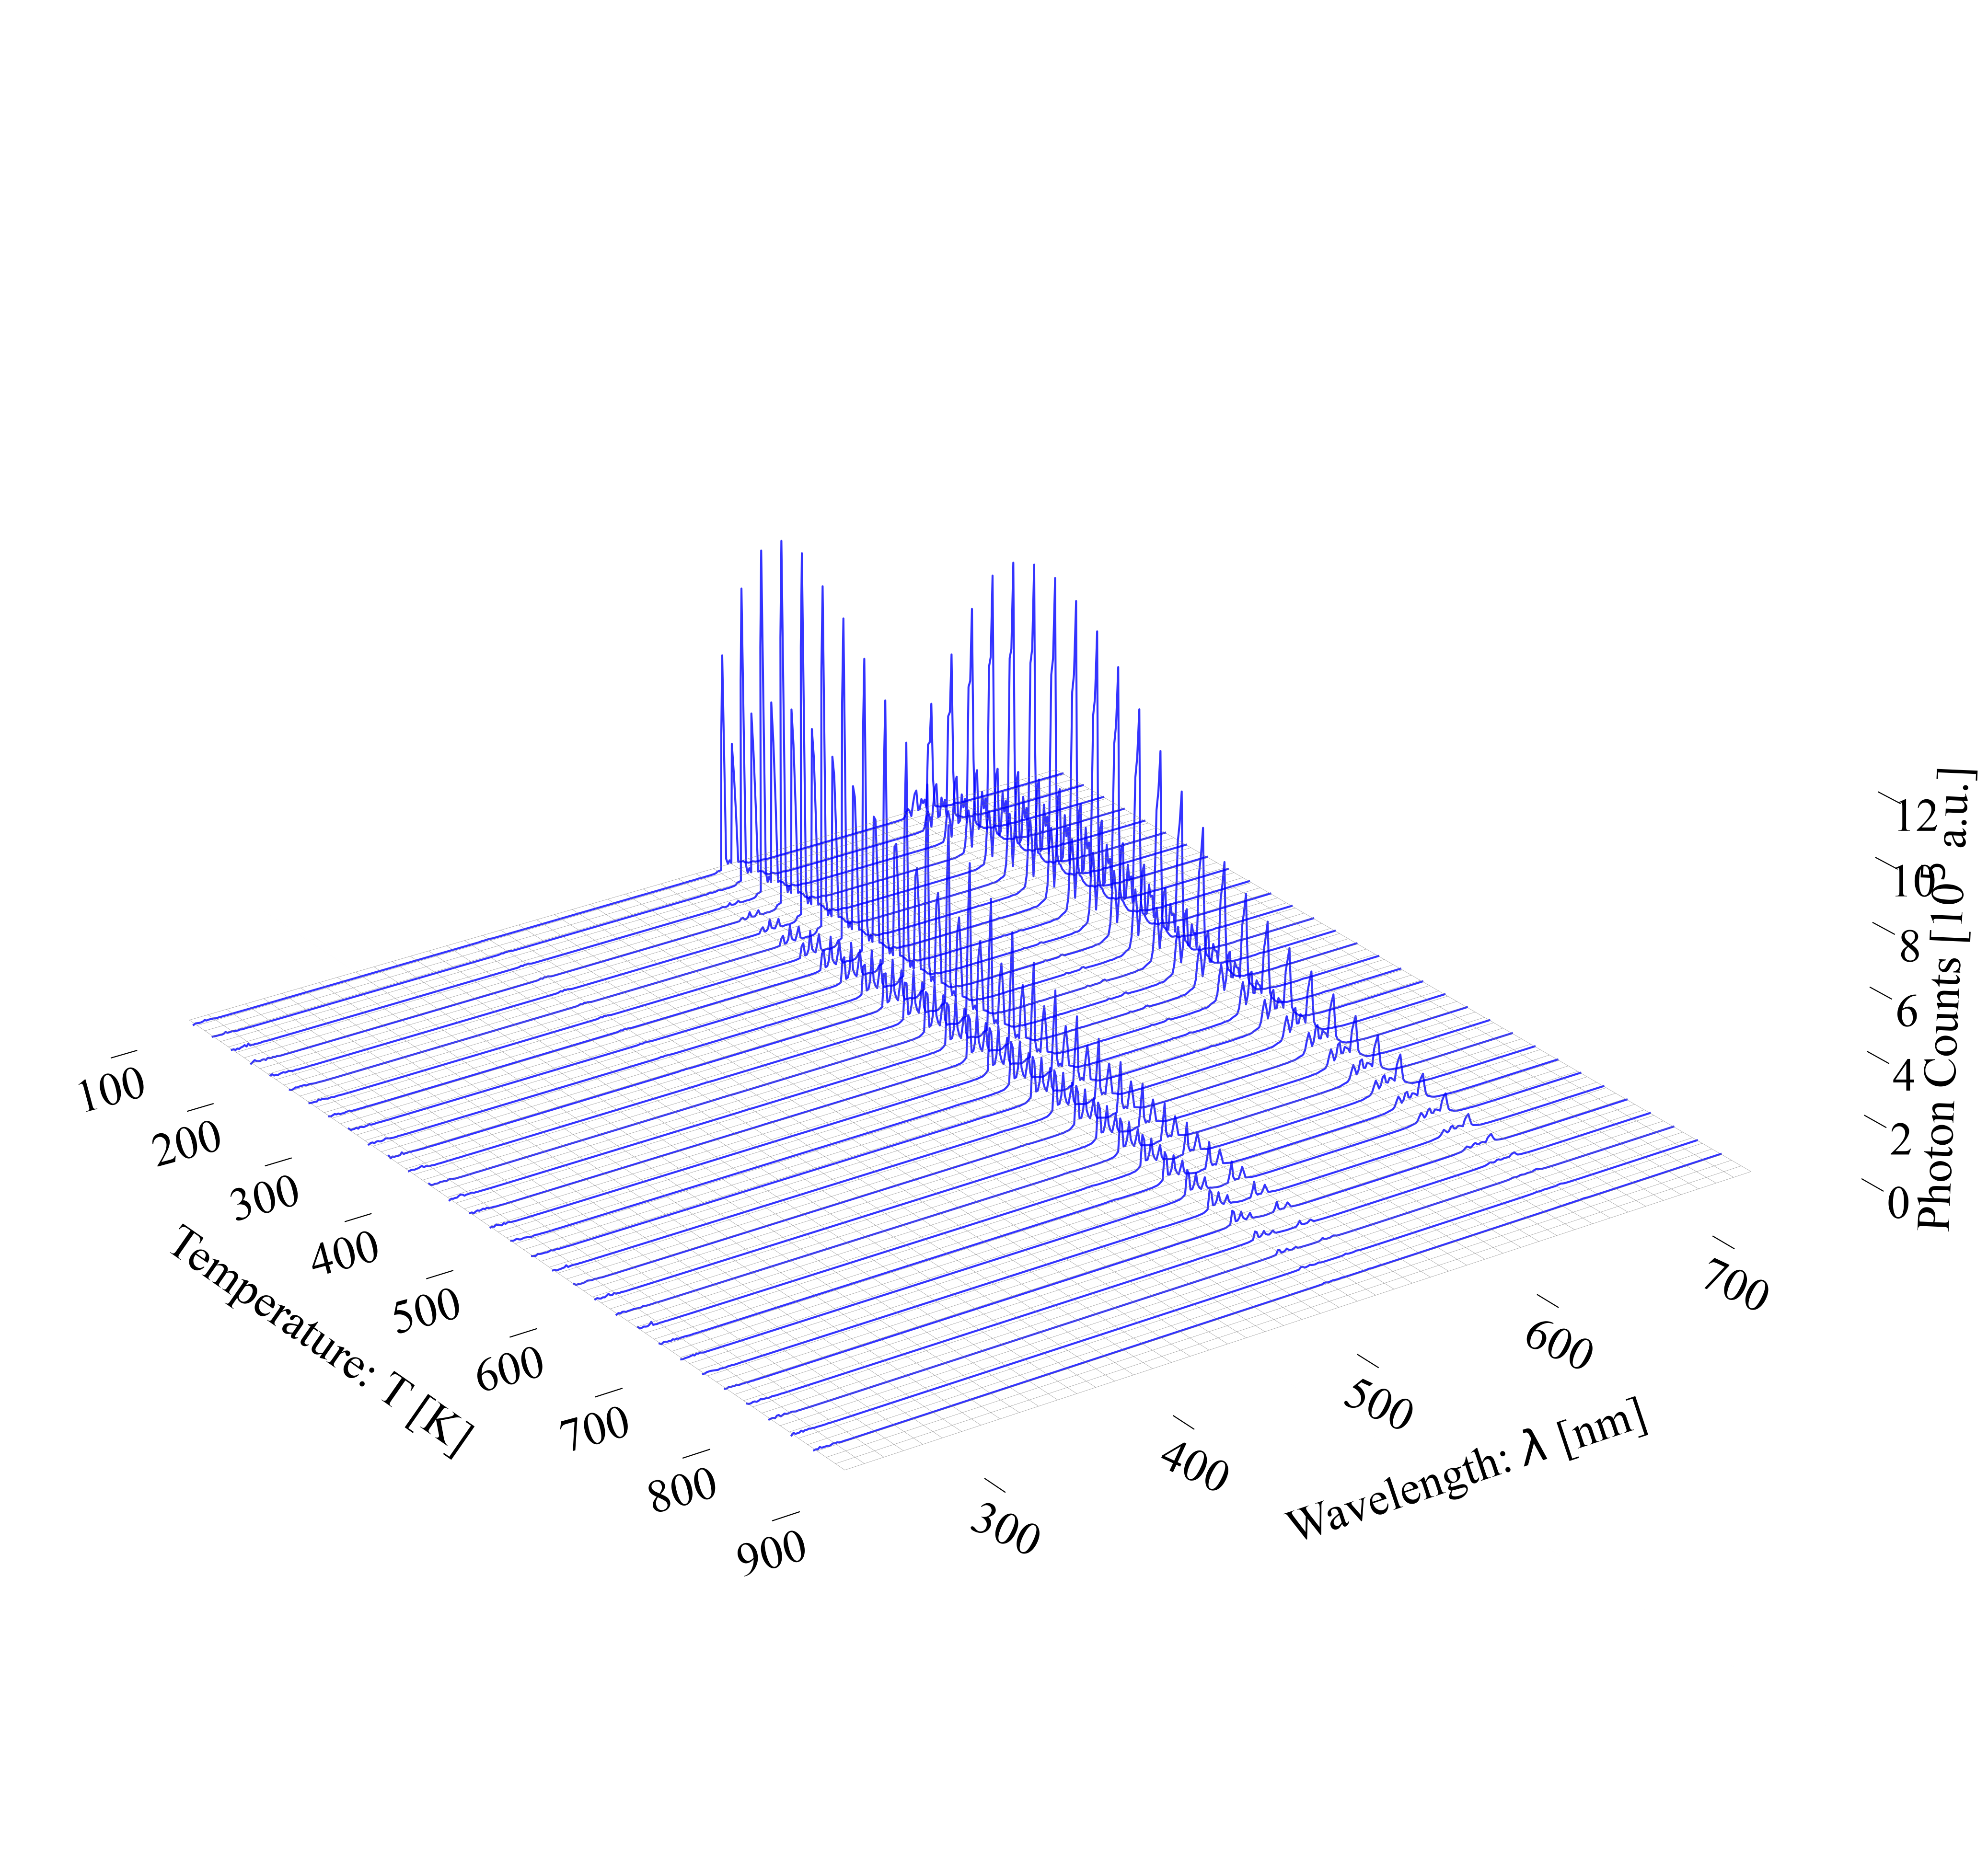

In [12]:
modFIR.graphCountsVsWavelength3D(gosArr, gosTemp)

### The user needs to define the integration limits (start and end wavelengths for manifolds)

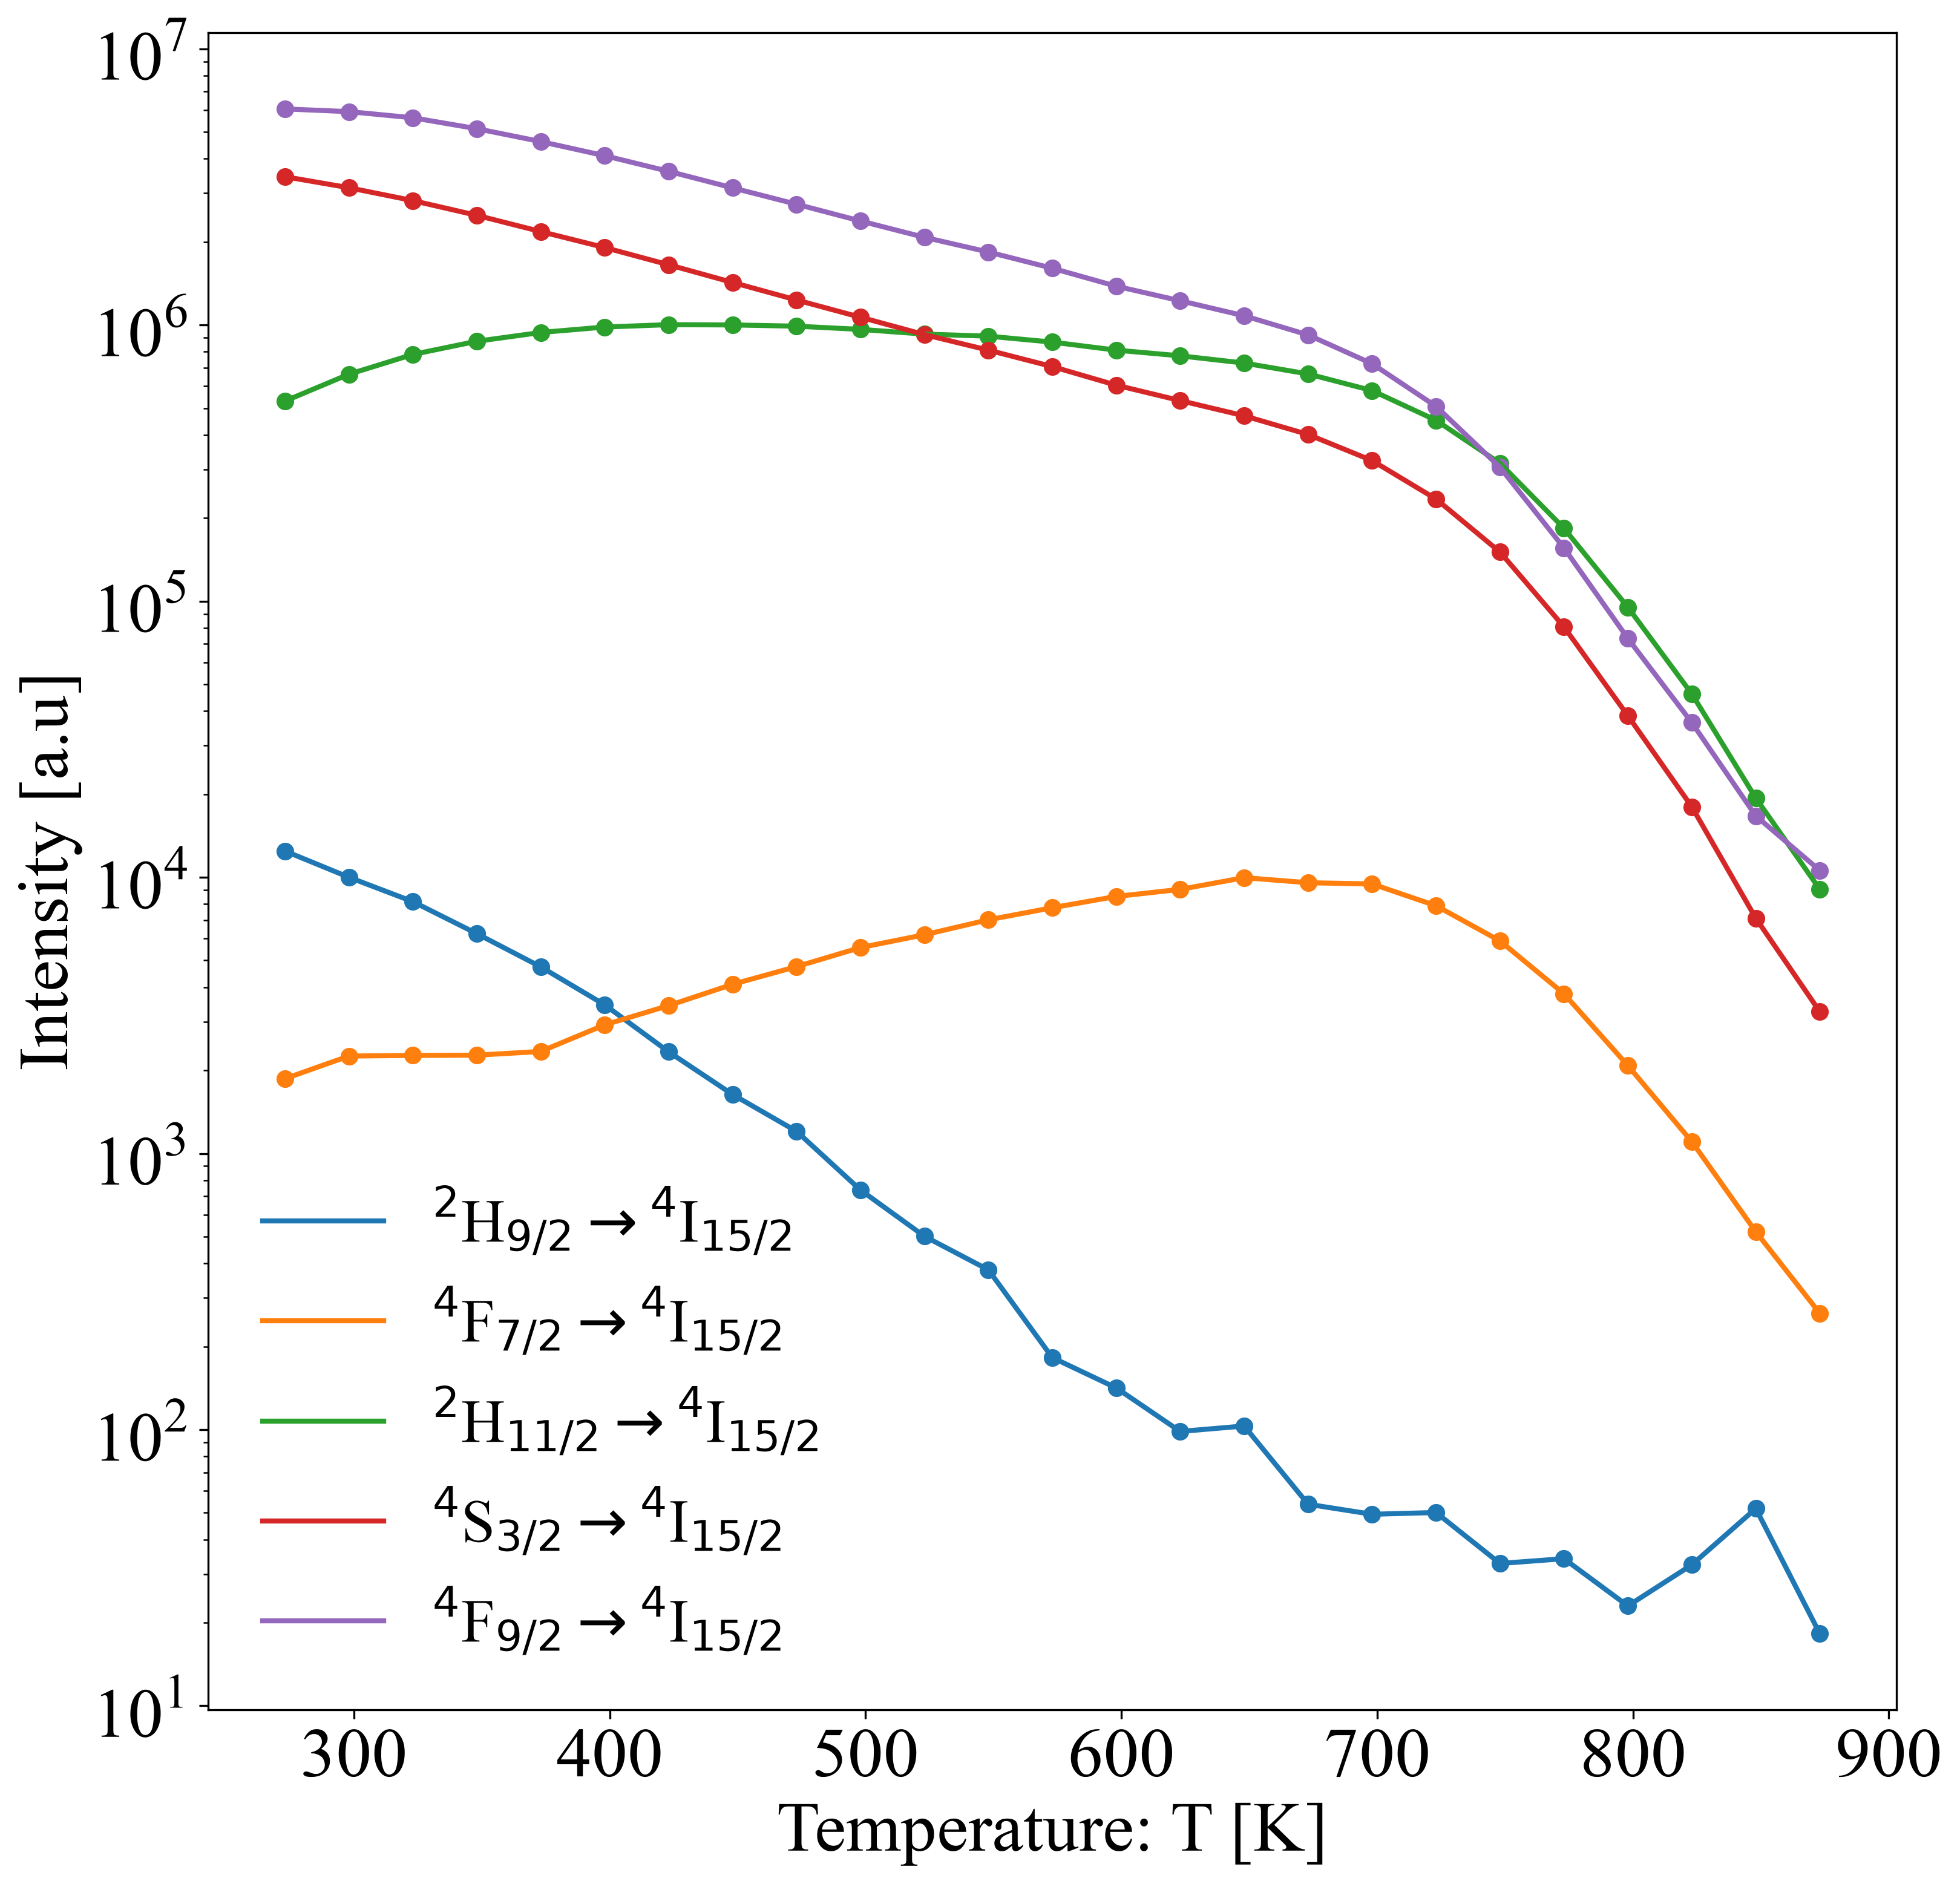

In [10]:
# integration limits can be chosen using the plotly graph above manually. You can zoom in as necessary.

modFIR.plotIntegratedIntensities(gosArr
                                 , gosTemp + 273
                                 , [406, 485, 515, 541, 640],[416, 505, 541, 576, 705] 
                                 , [r"$^2$H$_{9/2} \to ^4$I$_{15/2}$", r"$^4$F$_{7/2} \to ^4$I$_{15/2}$", r"$^2$H$_{11/2} \to ^4$I$_{15/2}$", r"$^4$S$_{3/2} \to ^4$I$_{15/2}$", r"$^4$F$_{9/2} \to ^4$I$_{15/2}$"] #labels for each manifolds
                                 , fromTempIdx=7 # if I want to not include sub-zero measurements
                                 , saveFigure=False
                                 , saveFileName = "out/integratedIntensitiesUC.pdf"
                                 )

### The user needs to define the limits to get the baseline count as well

In [15]:
baseCountArr    = modFIR.getBaselineCountSpectrum(gosArr, 450, 500)
len(baseCountArr) == len(gosTemp)

True

### Now, use the wavelength limits for the manifold corresponding to thermally coupled levels (or any manifolds you desire to compute FIR of) and the baseline computed above

In [17]:
gosFIR  = modFIR.getFIR(gosArr, 515, 541, 541, 576, baseCountArr)
gosFIR

array([1.58229878e-03, 4.49270135e-03, 1.08234562e-02, 2.26672039e-02,
       4.20371936e-02, 6.97344007e-02, 1.07394190e-01, 1.53920081e-01,
       2.11095580e-01, 2.77247545e-01, 3.49815201e-01, 4.31024647e-01,
       5.15386630e-01, 6.06936929e-01, 7.01585331e-01, 8.03775423e-01,
       9.03619590e-01, 1.00404254e+00, 1.12380450e+00, 1.22646909e+00,
       1.33943334e+00, 1.45281292e+00, 1.55265899e+00, 1.65691890e+00,
       1.79296288e+00, 1.92831406e+00, 2.09659229e+00, 2.27611062e+00,
       2.47300774e+00, 2.56540397e+00, 2.72645004e+00, 2.77712159e+00])

In [21]:
gosTempAbove0_inK = gosTemp[7:] + 273
print(gosTempAbove0_inK)

gosFIRAbove0_inK = gosFIR[7:]
print(gosFIRAbove0_inK)

len(gosFIRAbove0_inK) == len(gosTempAbove0_inK)

[273. 298. 323. 348. 373. 398. 423. 448. 473. 498. 523. 548. 573. 598.
 623. 648. 673. 698. 723. 748. 773. 798. 823. 848. 873.]
[0.15392008 0.21109558 0.27724754 0.3498152  0.43102465 0.51538663
 0.60693693 0.70158533 0.80377542 0.90361959 1.00404254 1.1238045
 1.22646909 1.33943334 1.45281292 1.55265899 1.6569189  1.79296288
 1.92831406 2.09659229 2.27611062 2.47300774 2.56540397 2.72645004
 2.77712159]


True

### the graphFIRAnalysis function gives you a detailed analysis of FIR relation with temperature, along with the sensitivities and temperature uncertainty

Some constants like 0.03% and 0.5% have been hardcoded in the code for temperature uncertainty calculation, as that is the value used for PMT devices (source: Brites 2016 paper), but feel free to change the values there if it differs for you

 relSens :  [0.01548807 0.0129984  0.01106414 0.00953156 0.00829669 0.00728713
 0.00645122 0.00575131 0.00515941 0.0046544  0.00422007 0.00384381
 0.00351571 0.0032279  0.00297404 0.00274899 0.00254855 0.00236925
 0.00220824 0.0020631  0.00193181 0.00181266 0.00170421 0.00160521
 0.00151459] 

  absSens :  [0.00217682 0.00260476 0.00299227 0.00333231 0.00362274 0.00386465
 0.00406106 0.00421598 0.00433387 0.00441921 0.0044763  0.0045091
 0.00452121 0.00451582 0.00449576 0.00446348 0.00442111 0.00437049
 0.00431319 0.00425057 0.00418376 0.00411374 0.00404134 0.00396727
 0.0038921 ] 

 uncertainty in general condition :  [0.32282913 0.38466259 0.45191054 0.52457298 0.6026499  0.68614131
 0.77504722 0.86936761 0.96910248 1.07425185 1.18481571 1.30079405
 1.42218689 1.54899421 1.68121602 1.81885232 1.9619031  2.11036838
 2.26424814 2.42354239 2.58825114 2.75837437 2.93391208 3.11486429
 3.30123099] 

 uncertainty in max SNR :  [0.01936975 0.02307976 0.02711463 0.03147438 0.03615899 0.04116

/Users/nabinchapagain/Library/Mobile Documents/com~apple~CloudDocs/randGit/firThermometry/src/firAnalysisModule.py:884: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(prop={'size': 20},framealpha=0)
/Users/nabinchapagain/Library/Mobile Documents/com~apple~CloudDocs/randGit/firThermometry/src/firAnalysisModule.py:891: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(prop={'size': 20},framealpha=0)
/Users/nabinchapagain/Library/Mobile Documents/com~apple~CloudDocs/randGit/firThermometry/src/firAnalysisModule.py:901: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend(prop={'size': 20},framealph

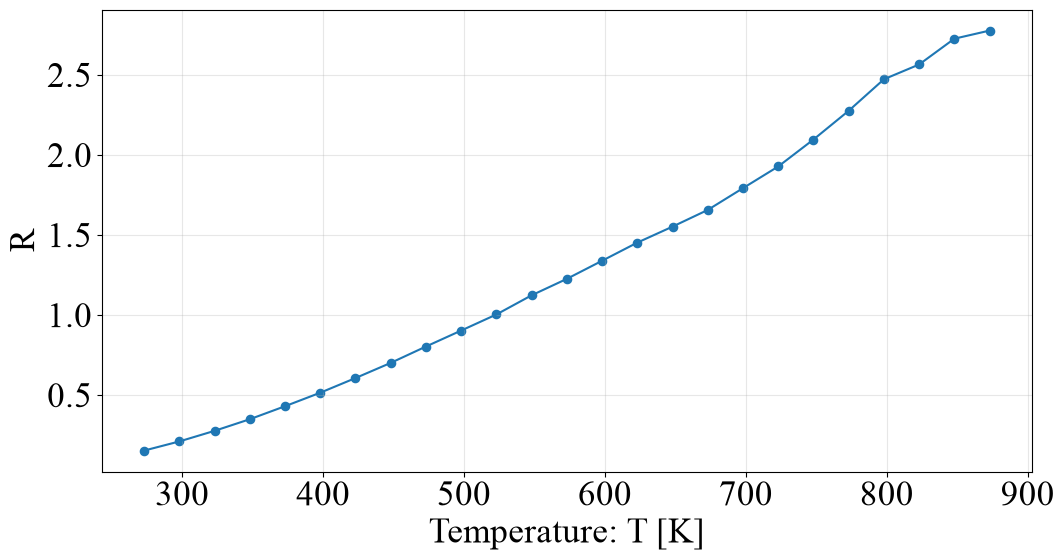

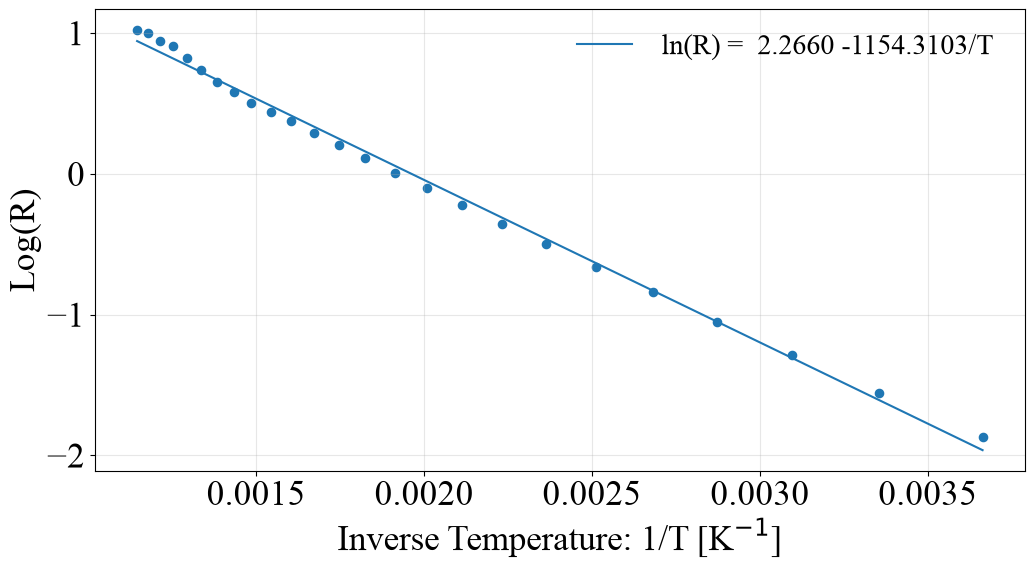

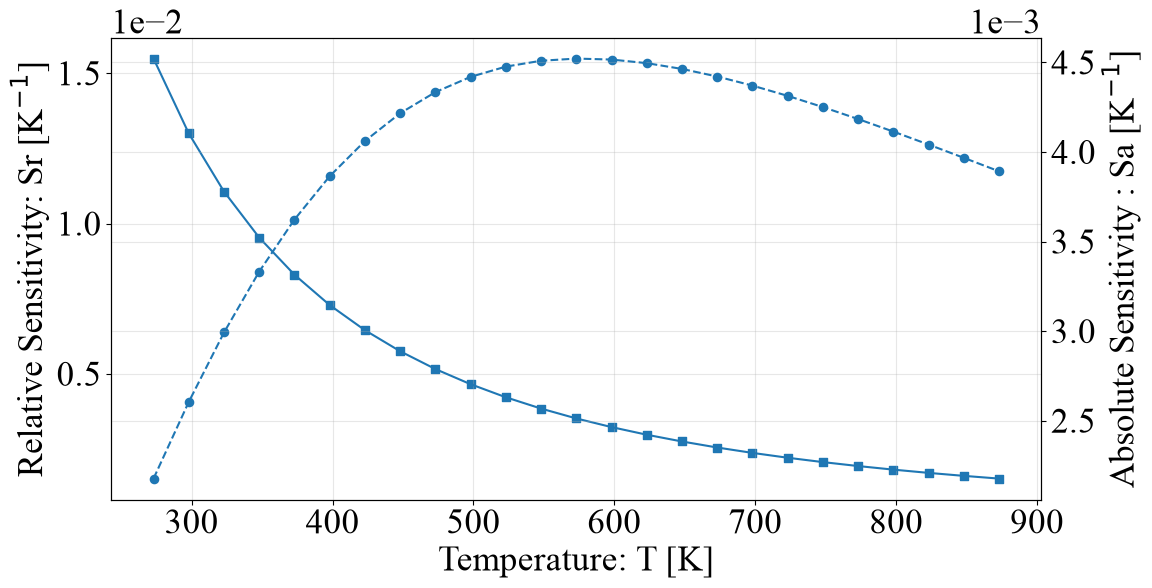

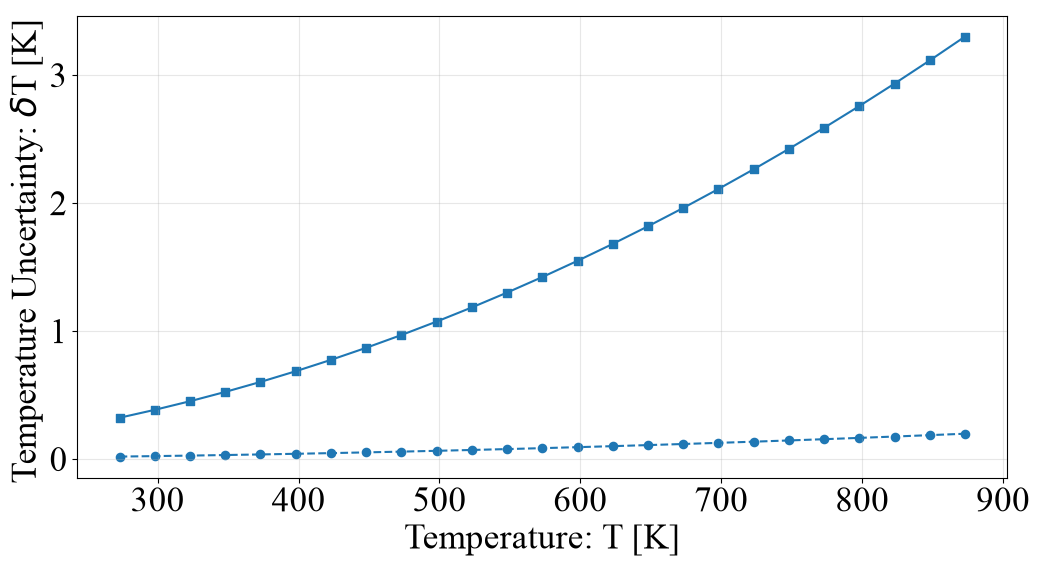

In [22]:
modFIR.graphFirAnalysis(gosFIRAbove0_inK, gosTempAbove0_inK)

### There it is, the complete FIR analysis module.

There are obviously more calculations that can be done to analyze it further but the hope of this project is to make the FIR analysis process easier and streamlined using the python program as written here.

###  Above function also handles multiple FIR analysis plots together as well if you'ld like to compare different mechanisms such as UC and DC or the performance of different phosphors for FIR thermometry and so on.

As an example, let me just break down the existing FIR array into smaller chunks to show thge application.


Currently, working with: 0:

 relSens :  [0.0658292  0.04178886 0.02886339 0.02112412 0.01612651] 

  absSens :  [9.16910707e-05 2.15988095e-04 3.55461056e-04 4.82300083e-04
 5.84080520e-04] 

 uncertainty in general condition :  [0.07595414 0.11964912 0.17322984 0.23669631 0.31004851] 

 uncertainty in max SNR :  [0.00455725 0.00717895 0.01039379 0.01420178 0.01860291] 

 temperature :  [ 98. 123. 148. 173. 198.] 

 for slope =  -632.2236417127124  and intercept =  -0.12513214653974553 


Currently, working with: 1:

 relSens :  [0.014056   0.01179654 0.01004112 0.00865025 0.00752956] 

  absSens :  [0.00215631 0.00249697 0.00279002 0.00303418 0.00323152] 

 uncertainty in general condition :  [0.35571988 0.42385311 0.49795247 0.57801797 0.66404959] 

 uncertainty in max SNR :  [0.02134319 0.02543119 0.02987715 0.03468108 0.03984298] 

 temperature :  [273. 298. 323. 348. 373.] 

 for slope =  -1047.579895847605  and intercept =  1.9626401263012094 


Currently, working with: 2:

 re

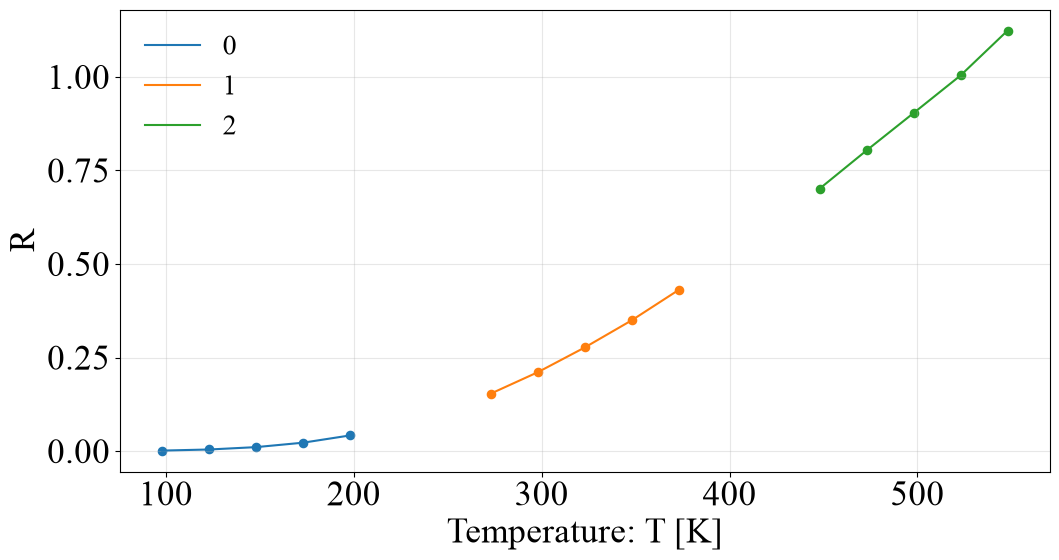

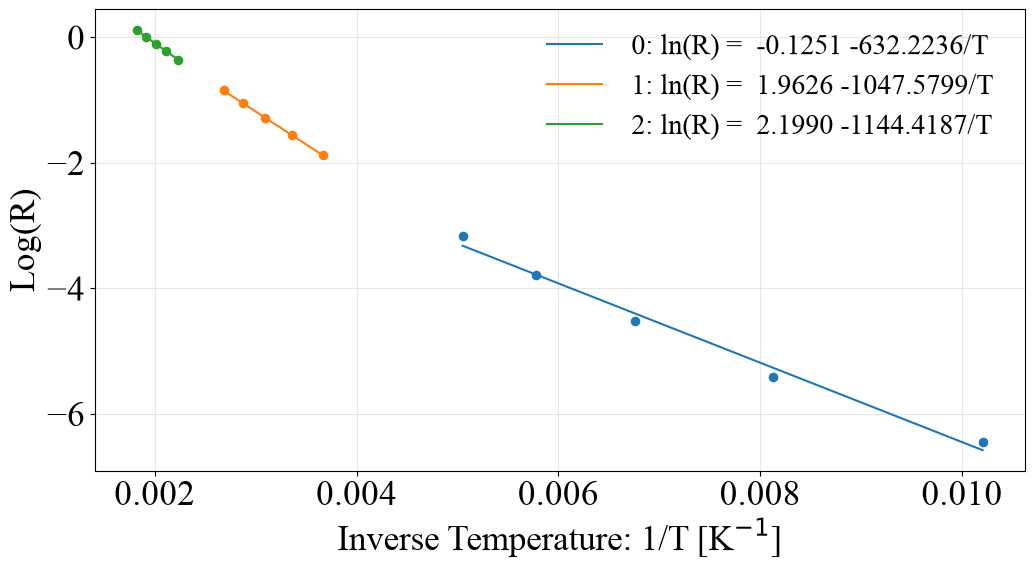

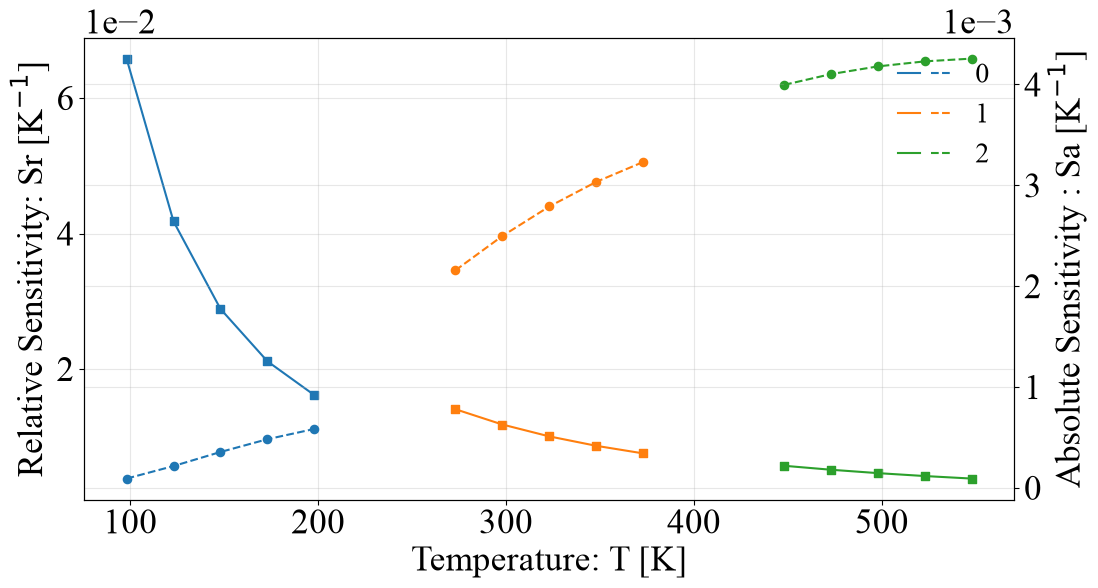

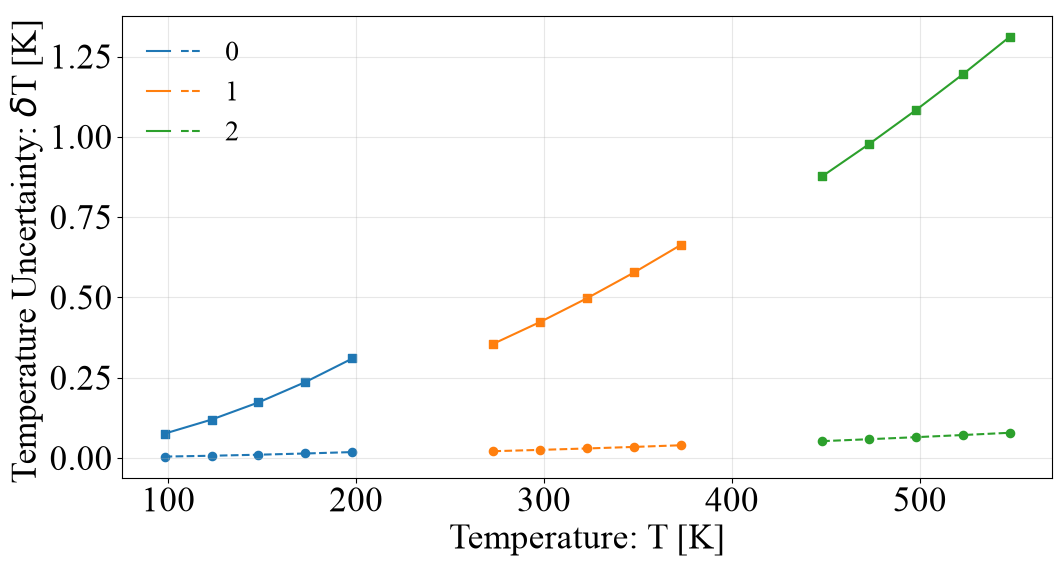

In [25]:
modFIR.graphFirAnalysis(np.array([gosFIR[0:5], gosFIR[7:12], gosFIR[14:19]]), np.array([gosTemp[0:5]+273, gosTemp[7:12]+273, gosTemp[14:19]+273]))

### In the example above, I was working with same dataset. That is why it looks like the three plots are broken parts of the same plot, which in fact they are.

Note: make sure the numpy arrays you pass for the FIR analysis all have same dimensions. It should not be 1 by 5, 1 by 7, 1 by 8, all of them should be 1 by n for some constant n.